# Liquidity Risk Optimisation under Cash Flow Uncertainty
This notebook demonstrates a stochastic optimisation model integrating simulation, optimisation, and risk analysis.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## Problem Setup

Firms must manage liquidity under uncertain cash flows. The model determines optimal allocation across:

- Cash holding  
- Borrowing  
- Investment  

The objective is to maximize returns while maintaining liquidity constraints.

In [8]:
!cd src && python3 simulation.py

Simulation complete. Data saved.


In [9]:
!cd src && python3 optimization.py

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/cf/b67bw93d00d07rwfc2gbg_ym0000gn/T/710584da32b34ca085d07765e67b4f2e-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/cf/b67bw93d00d07rwfc2gbg_ym0000gn/T/710584da32b34ca085d07765e67b4f2e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 29 COLUMNS
At line 113 RHS
At line 138 BOUNDS
At line 151 ENDATA
Problem MODEL has 24 rows, 36 columns and 59 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 10 (-14) rows, 31 (-5) columns and 40 (-19) elements
Perturbing problem by 0.001% of 0.01 - largest nonzero change 9.566049e-07 ( 0.011479259%) - largest zero change 8.5604312e-07
0  Obj 32.969934 Primal inf 36047.29 (10) Dual inf 0.091647366 (11)
18  Obj 307.10

In [11]:
!cd src && python3 risk.py

VaR  (95%): -156.39
CVaR (95%): -122.06


In [12]:
df = pd.read_csv("results/raw_results.csv")
df.head()

,final_cash,total_borrow,total_invest,objective,scenario
0,500.0,2592.7053,39967.07600,307.131914,0
1,500.0,0.0000,47237.84320,393.648693,1
2,500.0,0.0000,32819.26784,273.493899,2
3,500.0,0.0000,34884.13816,290.701151,3
4,500.0,0.0000,38027.89910,316.899159,4


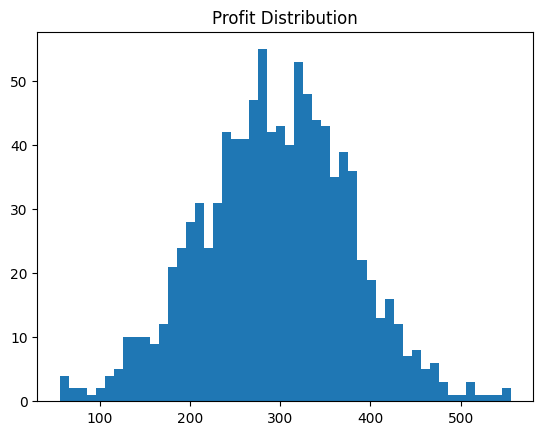

In [13]:
plt.hist(df["objective"], bins=50)
plt.title("Profit Distribution")
plt.show()

In [18]:
from IPython.display import HTML

HTML("""
<h3>Dashboard</h3>
<img src="results/dashboard.png" width="700">

<h3>Risk-Return Frontier</h3>
<img src="results/risk_return_frontier.png" width="500">
""")

## Interpretation

The model operates in a surplus regime where firms generate sufficient internal cash flows.

Profitability remains positive across scenarios, and CVaR shows limited downside risk even under extreme conditions.

In [14]:
pd.read_csv("sensitivity_results.csv")

,scenario,mean_profit,cvar
0,borrow_8,395.814501,-226.91
1,borrow_12,334.073603,-149.62
2,borrow_16,339.317252,-158.38


In [15]:
pd.read_csv("volatility_results.csv")

,scenario,mean_profit,cvar
0,vol_10,335.102291,-210.09
1,vol_18,335.419564,-161.45
2,vol_28,336.956605,-116.95


In [16]:
pd.read_csv("shock_results.csv")

,scenario,mean_profit,cvar
0,shock_5,357.939441,-188.53
1,shock_10,336.545667,-160.60
2,shock_20,300.843082,-114.62


## Key Findings

- Lower borrowing rates increase profit but increase downside exposure  
- Volatility affects distribution shape rather than mean  
- Higher shock frequency reduces profit and induces conservative behavior  

The model highlights how firms adjust liquidity strategies under uncertainty.